# Introducción y objetivo del taller #3:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhonattanreales21/nlp_icesi/blob/main/unidad_2/Cano_Reales_nlp_with_lstm.ipynb)

**Taller de NLP para clasificación de texto: Transformers VS LSTM**

Integrantes:
- Andres Cano
- Jhonattan Reales

Para este notebook/Taller implementaremos un clasificador de noticias (4 categorias) del dataset ag_news en inglés.  
En el taller anterior se implementó solo un modelo basado en LSTM para llevar a cabo la tarea de clasificación de texto. Para este taller, se implementará un modelo basado en Transformers utilizando módulos definidos de PyTorch y se comparará su desempeño frente al modelo recurrente. Además, se llevará a cabo un analisis sencillo de tuneo de hiperparametros para el modelo Transformer, enfocado en encontrar mejoras en la tarea de clasificación de nuestro dataset.

A lo largo de este notebook llevaremos a cabo los siguientes pasos:
- Exploraremos el dataset, efectuando pasos de exploración de datos y de resultados cuando corresponda.
- Definiremos las arquitecturas base de ambos modelos (LSTM & Transformers) y sus implicaciones.
- Entrenaremos, evaluaremos y compararemos el desempeño de los modelos base propuestos.
- Desarrollaremos un tuneo de hiperparametros sencillo del modelo Transformer, en busqueda de posibles configuraciones que mejoren el desempeño de nuestras clasificaciones.
- Implementaremos el mejor modelo clasificador tipo Transformers en un conjunto de noticias que el modelo no haya visto con anterioridad.

**Nota:**


# **Paquetes y Semilla**

In [36]:
import pkg_resources
import warnings
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns

import re
import math
from collections import Counter

from tqdm.auto import tqdm

In [4]:
# Usar GPU si existe
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

warnings.filterwarnings("ignore")

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = "google-colab" in installed_packages

SEED = 198

# Python
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Hace que operaciones CUDA sean deterministas (más reproducible, un poco más lento)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed fijada en:", SEED)

Device: cpu
Seed fijada en: 198


# 1. Lectura de datos
Este es un dataset tamaño mediano de articulos de noticias en idioma inglés con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [5]:
from datasets import load_dataset

ds = load_dataset("ag_news")
print(ds)

print("\nEjemplo train[0]:")
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Ejemplo train[0]:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


# 2. EDA
Procedemos a realizar un analisis exploratorio basico de las noticias y los labels de estas, con la finalidad de hacernos una idea de las particularidades de nuestro dataset y la posible necesidad de realizar pre-procesamientos.

## Distribucion de Clases

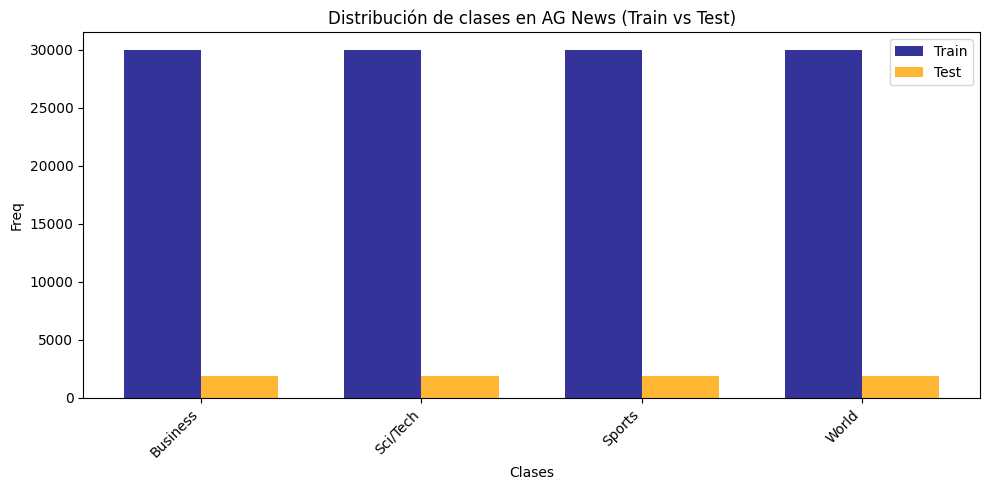

In [6]:
# Distribucion de clases en TRAIN y TEST
label_counts_train = Counter(ds["train"]["label"])
label_counts_test = Counter(ds["test"]["label"])

label_names = ds["train"].features["label"].names

# Conteo por nombre para train y test
counts_by_name_train = {label_names[k]: v for k, v in label_counts_train.items()}
counts_by_name_test = {label_names[k]: v for k, v in label_counts_test.items()}

# Preparamos datos para graficar
names = list(counts_by_name_train.keys())
counts_train = [counts_by_name_train[n] for n in names]
counts_test = [counts_by_name_test[n] for n in names]

# Graficamos la distribución de clases en train y test
x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, counts_train, width, label="Train", color="navy", alpha=0.8)
plt.bar(x + width / 2, counts_test, width, label="Test", color="orange", alpha=0.8)
plt.xlabel("Clases")
plt.ylabel("Freq")
plt.title("Distribución de clases en AG News (Train vs Test)")
plt.xticks(x, names, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

**Notas:**  
- Podemos observar que el dataset tanto de train como test, presentan una distribución de clases muy pareja, lo que en cierta medida disminuye la probabilidad de tener inconvenientes de desbalance a la hora de realizar la predicción de los labels de las noticias en el test set (predicción multiclase).

## Longitud de tokens por noticia

- Este analisis nos puede ayudar a definir la posible longitud de tokens a utilizar.
- En este caso estamos utilizando un tokenizador sencillo para el EDA, pero para el modelo, utilizaremos un tokenizador mas moderno lo cual extienda el numero de tokens.

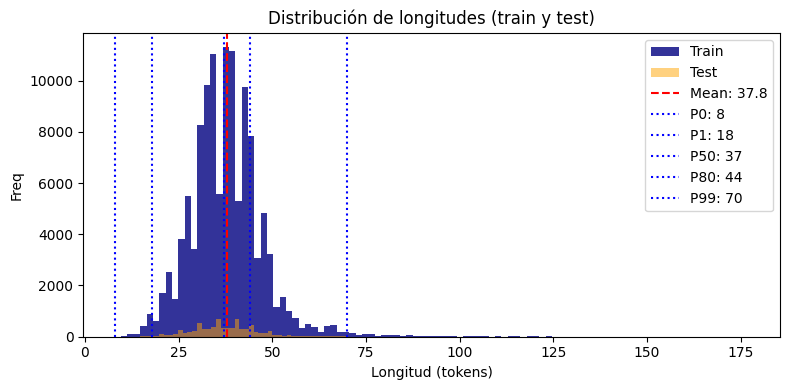

In [7]:
# Función simple de tokenización (solo para análisis de longitud, no para el modelo)
def simple_word_tokenizer(text: str):
    return text.lower().split()


# Analizamos la distribución de longitudes (en tokens) del texto
lengths_train = np.array([len(simple_word_tokenizer(t)) for t in ds["train"]["text"]])
lengths_test = np.array([len(simple_word_tokenizer(t)) for t in ds["test"]["text"]])

# Graficamos la distribución de longitudes y marcamos percentiles clave
percentiles = [0, 1, 50, 80, 99]
pvals_train = [int(np.percentile(lengths_train, p)) for p in percentiles]

plt.figure(figsize=(8, 4))
plt.hist(lengths_train, bins=100, color="navy", alpha=0.8, label="Train")
plt.hist(lengths_test, bins=100, color="orange", alpha=0.5, label="Test")
plt.axvline(
    lengths_train.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {lengths_train.mean():.1f}",
)
for p, val in zip(percentiles, pvals_train):
    plt.axvline(val, color="blue", linestyle=":", label=f"P{p}: {val}")
plt.xlabel("Longitud (tokens)")
plt.ylabel("Freq")
plt.title("Distribución de longitudes (train y test)")
plt.legend()
plt.tight_layout()
plt.show()

### Longitud de tokens por label y conjunto de datos

En este punto podemos analizar la heterogeneidad de la distribución de tokens por cada uno de los labels

In [8]:
# Percentiles de longitud de tokens por clase (label) en TRAIN y TEST

percentiles_by_class = [1, 5, 25, 50, 75, 95, 99]

for split in ["train", "test"]:
    print(f"\n{'='*70}\nSplit: {split.upper()}\n{'='*70}")

    texts = ds[split]["text"]
    labels = ds[split]["label"]

    for class_id, class_name in enumerate(label_names):
        # Obtenemos las longitudes de tokens para los textos por cada clase
        class_lengths = np.array(
            [
                len(simple_word_tokenizer(t))
                for t, y in zip(texts, labels)
                if y == class_id
            ]
        )

        # Calculamos percentiles para cada clase
        pvals = np.percentile(class_lengths, percentiles_by_class)
        pvals_str = " | ".join(
            [f"P{p:>2}: {int(v):>3}" for p, v in zip(percentiles_by_class, pvals)]
        )

        print(
            f"{class_name:10s} -> "
            f"n={len(class_lengths):5d} | "
            f"mean={class_lengths.mean():6.2f} | "
            f"min={class_lengths.min():3d} | max={class_lengths.max():3d} | "
            f"{pvals_str}"
        )


Split: TRAIN
World      -> n=30000 | mean= 38.88 | min= 11 | max=145 | P 1:  19 | P 5:  23 | P25:  33 | P50:  39 | P75:  44 | P95:  55 | P99:  75
Sports     -> n=30000 | mean= 37.77 | min=  8 | max=151 | P 1:  21 | P 5:  26 | P25:  32 | P50:  37 | P75:  42 | P95:  52 | P99:  66
Business   -> n=30000 | mean= 37.54 | min=  8 | max=134 | P 1:  18 | P 5:  25 | P25:  32 | P50:  37 | P75:  42 | P95:  50 | P99:  58
Sci/Tech   -> n=30000 | mean= 37.19 | min=  8 | max=177 | P 1:  16 | P 5:  20 | P25:  30 | P50:  36 | P75:  42 | P95:  56 | P99:  84

Split: TEST
World      -> n= 1900 | mean= 38.55 | min= 15 | max=106 | P 1:  18 | P 5:  22 | P25:  32 | P50:  39 | P75:  44 | P95:  53 | P99:  71
Sports     -> n= 1900 | mean= 37.57 | min= 17 | max= 90 | P 1:  21 | P 5:  26 | P25:  32 | P50:  37 | P75:  42 | P95:  51 | P99:  66
Business   -> n= 1900 | mean= 37.63 | min= 14 | max=126 | P 1:  18 | P 5:  26 | P25:  33 | P50:  37 | P75:  42 | P95:  50 | P99:  57
Sci/Tech   -> n= 1900 | mean= 37.15 | min=

**Notas:**  
- La longitud de los tokens por documento es variable, tanto aa nivel general como separado por clases. Existen noticias con muy pocos tokens, incluso por debajo de 10 tokens, en contraste con noticias de mas de 100 tokens.
- Si observamos la longitud de los tokens dividido por Train y Test, notamos que la distribución es ciertamente similar, con la diferencia de que en el conjunto de Test las noticias tienen menos variablidad y noticias con longitudes extremas (minimos y maximos).

El tema de la variabilidad en los tokens por documento, nos lleva a la necesidad de:
- Restringir la longitud de los tokens por documento (ej: a 100 tokens).
- Hacer clipping para los documentos que excedan el limite que estableceremos.
- Utilizar padding para rellenar los tokens que nos hacen falta en algunos documentos.

## Nubes de palabras

Generamos nubes de palabras por cada clase para obtener una comprensión visual rápida del vocabulario más frecuente en cada tipo de noticia. Esta visualización nos permite generar intuición sobre qué palabras los modelos podrían aprender a asociar con cada clase. Esta exploración visual complementa el análisis cuantitativo previo y nos ayuda a anticipar posibles desafíos en la tarea de clasificación.

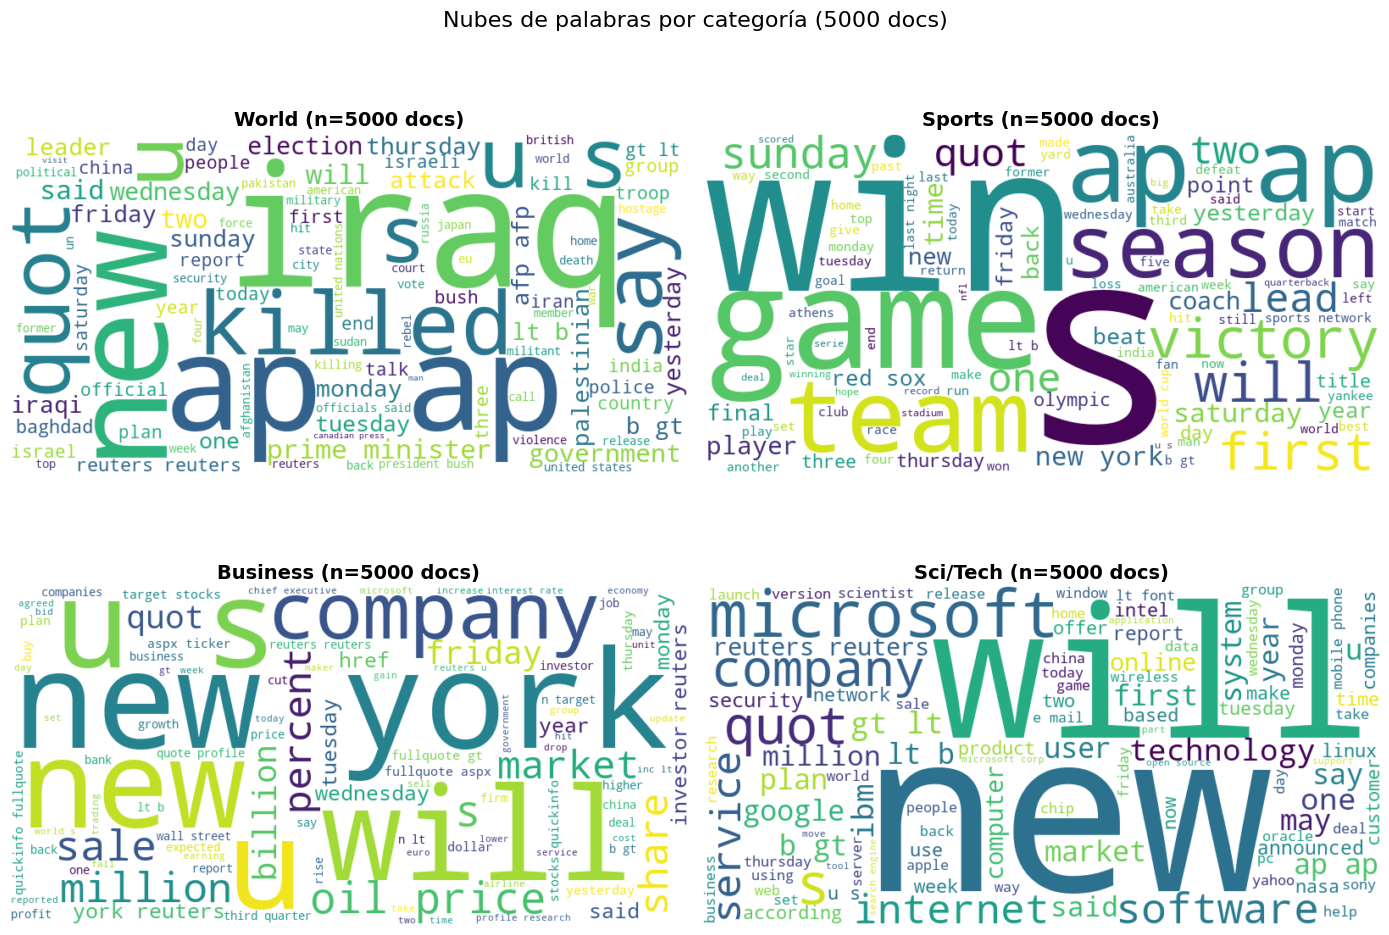

In [9]:
## Nube de palabras por clase

# Número máximo de documentos por clase para la nube de palabras
max_docs_per_class = 5000

# Crear figura con subplots para cada clase
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Para cada clase, generar nube de palabras
class_names = ds["train"].features["label"].names
for class_idx, class_name in enumerate(class_names):
    # Filtrar documentos de esta clase
    class_texts = [
        text
        for text, label in zip(ds["train"]["text"], ds["train"]["label"])
        if label == class_idx
    ]

    # Limitar a max_docs_per_class documentos (escogiendo al azar)
    if len(class_texts) > max_docs_per_class:
        class_texts = random.sample(class_texts, max_docs_per_class)

    # Concatenar todos los textos de la clase
    combined_text = " ".join(class_texts)

    # Tokenizador simple
    tokens = simple_word_tokenizer(combined_text)
    clean_text = " ".join(tokens)

    # Generar nube de palabras
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10,
    ).generate(clean_text)

    # Mostrar en el subplot correspondiente
    axes[class_idx].imshow(wordcloud, interpolation="bilinear")
    axes[class_idx].axis("off")
    axes[class_idx].set_title(
        f"{class_name} (n={len(class_texts)} docs)", fontsize=14, fontweight="bold"
    )

plt.tight_layout()
plt.suptitle(
    f"Nubes de palabras por categoría ({max_docs_per_class} docs)", fontsize=16, y=1.02
)
plt.show()

**Notas:**

- Cada categoría tiene palabras muy claras que la identifican. Deportes tiene “olympic”, “game”, “medal”; Tecnología tiene “microsoft”, “software”; Negocios tiene “company”, sale; Mundo tiene “government”, “iraq”. Esto indica que sí hay señales visibles que ayudan a diferenciarlas.

- Hay terminos que no queda muy claro si ayudan a clasificar, como es el caso de "ap" que se repite en todas las clases. Términos como “said”, “reuters” o días de la semana aparecen en todas las clases tambien. 

- Negocios y Tecnología se parecen bastante. Comparten muchas palabras relacionadas con empresas y mercado. Este aspecto puede ser la causa de posibles dificultades para el modelo en terminos de diferenciar una categoria de la otra.

# 3. Preparación de los datos

En el taller anterior se utilizó una tokenización sencilla basada en separación por espacios, suficiente para construir un primer modelo recurrente y comprender el flujo general de una tarea de clasificación de texto. Sin embargo, este enfoque tiene limitaciones importantes: depende fuertemente del vocabulario observado, no maneja bien variaciones y puede fragmentar de manera poco robusta textos reales.

Para este taller se utilizará un tokenizador moderno de la librería Hugging Face, específicamente el correspondiente al modelo `distilbert-base-uncased`. Aunque en este notebook no se empleará el modelo DistilBERT, sí resulta útil aprovechar su tokenizador, ya que implementa **subword tokenization**. Esto permite representar palabras desconocidas o poco frecuentes a través de fragmentos más estables del lenguaje, reduciendo problemas de vocabulario y mejorando la flexibilidad del preprocesamiento.

In [10]:
from transformers import AutoTokenizer

# Utilizaremos el tokenizador de DistilBERT por ser moderno, robusto y ampliamente usado.
# De esta manera aprovecharemos su estrategia de subwords.
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer)
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Pad token: {tokenizer.pad_token} -> id {tokenizer.pad_token_id}")
print(f"CLS token: {tokenizer.cls_token} -> id {tokenizer.cls_token_id}")
print(f"SEP token: {tokenizer.sep_token} -> id {tokenizer.sep_token_id}")

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
Vocab size: 30522
Pad token: [PAD] -> id 0
CLS token: [CLS] -> id 101
SEP token: [SEP] -> id 102


El resultado confirma que se cargó correctamente el tokenizador el cual cuenta con un vocabulario de 30.522 tokens y una longitud máxima de secuencia de 512. También se identifican los principales tokens especiales que se utilizarán durante el preprocesamiento: `[PAD]` para completar secuencias cortas, `[CLS]` como token inicial y `[SEP]` como separador de segmentos, cada uno con su respectivo token ID.

In [11]:
tokens = sorted(tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print("Primeros 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[10000:10015]])
print("Últimos 15 tokens:")
print([f"{tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Primeros 15 tokens:
['[PAD]', '[unused0]', '[unused1]', '[unused2]', '[unused3]', '[unused4]', '[unused5]', '[unused6]', '[unused7]', '[unused8]', '[unused9]', '[unused10]', '[unused11]', '[unused12]', '[unused13]']
15 tokens de en medio:
['raven', 'travis', 'classics', 'proven', 'voltage', 'pillow', 'fists', 'butt', '1842', 'interpreted', '##car', '1839', 'gage', 'telegraph', 'lens']
Últimos 15 tokens:
['##高', '##龍', '##龸', '##ﬁ', '##ﬂ', '##！', '##（', '##）', '##，', '##－', '##．', '##／', '##：', '##？', '##～']


A continuación se inspecciona cómo el tokenizador moderno segmenta algunos ejemplos del dataset. Este análisis permite observar que la tokenización ya no depende únicamente de separar por espacios, sino que puede dividir palabras en subunidades. Esto resulta útil cuando aparecen términos poco frecuentes, nombres propios, siglas o variaciones en las palabras de documentos.

In [12]:
# Seleccionamos algunos ejemplos del conjunto de entrenamiento para inspeccionar la tokenización
sample_idxs = random.sample(range(len(ds["train"])), 3)

for idx in sample_idxs:
    text = ds["train"][idx]["text"]
    label = ds["train"][idx]["label"]
    label_name = ds["train"].features["label"].names[label]

    encoded = tokenizer(text)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

    print("_" * 10)
    print(f"Ejemplo {idx} - Clase: {label_name}")
    print("- Texto original:")
    print(text)
    print("\n- Tokens generados:")
    print(tokens)
    print(f"\n- Número de tokens: {len(tokens)}")

__________
Ejemplo 44685 - Clase: Business
- Texto original:
Boston Scientific stent sales set record Boston Scientific Corp. said yesterday it sold \$8.3 million worth of its Taxus drug-coated cardiac stents per day this month, a record level the Natick medical 

- Tokens generados:
['[CLS]', 'boston', 'scientific', 'ste', '##nt', 'sales', 'set', 'record', 'boston', 'scientific', 'corp', '.', 'said', 'yesterday', 'it', 'sold', '\\', '$', '8', '.', '3', 'million', 'worth', 'of', 'its', 'tax', '##us', 'drug', '-', 'coated', 'cardiac', 'ste', '##nts', 'per', 'day', 'this', 'month', ',', 'a', 'record', 'level', 'the', 'nat', '##ick', 'medical', '[SEP]']

- Número de tokens: 46
__________
Ejemplo 118420 - Clase: World
- Texto original:
Russia to release massacre files Russia agrees to allow Polish authorities to examine Soviet archives on what Poles call the Katyn Forest massacre of 1940.

- Tokens generados:
['[CLS]', 'russia', 'to', 'release', 'massacre', 'files', 'russia', 'agrees', 'to

En los ejemplos anteriores puede observarse que el tokenizador agrega tokens especiales como `[CLS]` y `[SEP]`, e introduce fragmentación por subpalabras en ciertos casos. Este comportamiento es relevante porque ofrece una representación más flexible que la tokenización por espacios, especialmente en presencia de palabras raras, compuestas o no vistas exactamente durante el entrenamiento.

### Longitudes de secuencias con tokenizador HF

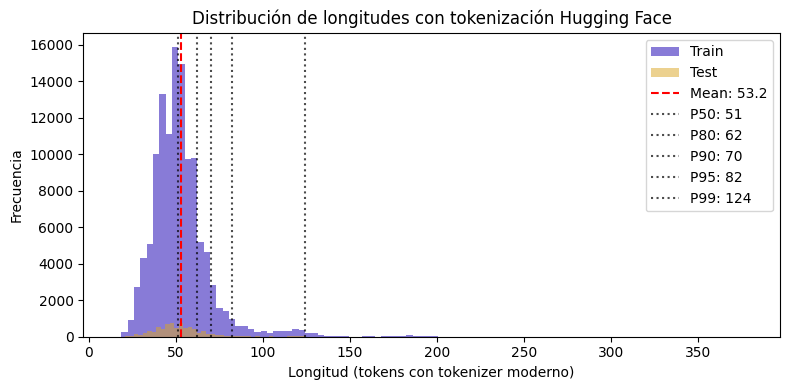

In [13]:
# Analizamos la distribución de longitudes usando el tokenizador moderno
# No aplicamos padding aquí; solo observamos cuántos tokens genera cada texto.
hf_lengths_train = np.array(
    [
        len(tokenizer(text, truncation=False)["input_ids"])
        for text in ds["train"]["text"]
    ]
)

hf_lengths_test = np.array(
    [len(tokenizer(text, truncation=False)["input_ids"]) for text in ds["test"]["text"]]
)

percentiles = [50, 80, 90, 95, 99]
pvals_hf_train = [int(np.percentile(hf_lengths_train, p)) for p in percentiles]

plt.figure(figsize=(8, 4))
plt.hist(hf_lengths_train, bins=100, color="slateblue", alpha=0.8, label="Train")
plt.hist(hf_lengths_test, bins=100, color="goldenrod", alpha=0.5, label="Test")
plt.axvline(
    hf_lengths_train.mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {hf_lengths_train.mean():.1f}",
)

for p, val in zip(percentiles, pvals_hf_train):
    plt.axvline(val, color="black", linestyle=":", alpha=0.7, label=f"P{p}: {val}")

plt.xlabel("Longitud (tokens con tokenizer moderno)")
plt.ylabel("Frecuencia")
plt.title("Distribución de longitudes con tokenización Hugging Face")
plt.legend()
plt.tight_layout()
plt.show()

**Notas:**

A partir de la distribución de longitudes tokenizadas, se definirá un valor máximo de secuencia (`max_length`) que permita cubrir la mayor parte de los ejemplos sin introducir un costo computacional excesivo.   

En este caso, se busca un equilibrio entre preservar información textual y mantener el entrenamiento manejable. 

Para este notebook se utilizará un valor de `max_length = 100` (pero se podria configurar despues).

### Tokenización del dataset (Completo)

El dataset de Hugging face lo tokenizaremos y lo dejamos listo para ser utilizado como un Dataset de pytorch

In [14]:
# Definimos la longitud máxima de secuencia a utilizar
max_length = 100


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )


# Aplicamos la tokenización al dataset completo
tokenized_ds = ds.map(tokenize_batch, batched=True)

# Renombramos la etiqueta para que sea más natural al trabajar en PyTorch
tokenized_ds = tokenized_ds.rename_column("label", "labels")

# Seleccionamos solo las columnas necesarias para el entrenamiento
tokenized_ds.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"],
)

print(tokenized_ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [15]:
tokenized_ds["train"][0]

{'labels': tensor(2),
 'input_ids': tensor([  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
          1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
          2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
          1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,

**notas:**

Con estos pasos queda preparada la representación tokenizada del dataset para su uso posterior en PyTorch. En particular, cada noticia queda representada mediante una secuencia de identificadores (`input_ids`) y una máscara de atención (`attention_mask`) que indica cuáles posiciones corresponden a texto real y cuáles a padding. 

En esta etapa no se construirán aún los `DataLoader`, ya que dicho proceso se integrará en la siguiente sección del notebook, donde se definirán los componentes comunes del pipeline de entrenamiento y evaluación. De esta manera, parámetros como el tamaño del batch podrán manejarse de forma más flexible dentro del proceso experimental.

Desde el punto de vista metodológico, esta sección también introduce una diferencia relevante frente al taller anterior: el uso de un tokenizador moderno basado en subpalabras.

## Separación de dataset en Train, Validation & Test

Partimos el conjunto de entrenamiento original en entrenamiento y validación

In [16]:
# Usamos una partición 90/10 manteniendo la semilla definida al inicio del notebook.
train_val_split = tokenized_ds["train"].train_test_split(test_size=0.1, seed=SEED)

train_dataset = train_val_split["train"]
val_dataset = train_val_split["test"]
test_dataset = tokenized_ds["test"]

print("Tamaños de los conjuntos:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Tamaños de los conjuntos:
Train: 108000
Validation: 12000
Test: 7600


In [ ]:
from collections import Counter

# Revisamos la distribución de clases en cada subconjunto
train_counts = Counter(train_dataset["labels"].tolist())
val_counts = Counter(val_dataset["labels"].tolist())
test_counts = Counter(test_dataset["labels"].tolist())

num_classes = len(ds["train"].features["label"].names)

split_distribution = pd.DataFrame(
    {
        "Clase": class_names,
        "Train": [train_counts[i] for i in range(num_classes)],
        "Validation": [val_counts[i] for i in range(num_classes)],
        "Test": [test_counts[i] for i in range(num_classes)],
    }
)

split_distribution

,Clase,Train,Validation,Test
0,World,27070,2930,1900
1,Sports,26996,3004,1900
2,Business,26962,3038,1900
3,Sci/Tech,26972,3028,1900


**Notas:**

La distribución de clases en los subconjuntos obtenidos se mantiene razonablemente balanceada, lo cual resulta conveniente para el entrenamiento y la evaluación de los modelos. Dado que AG News es un dataset relativamente equilibrado, contamos con una proporción similar de ejemplos por categoría sin necesidad de aplicar técnicas adicionales de balanceo.

# 4. Definición de arquitecturas

En esta sección se presentan las arquitecturas base que serán utilizadas en el desarrollo del notebook. Dado que el objetivo del taller es comparar un enfoque secuencial clásico frente a un enfoque basado en Transformers, primero se definirán los componentes comunes del pipeline de entrenamiento y evaluación, de modo que ambos modelos compartan condiciones experimentales comparables. Posteriormente, se describirá la arquitectura base LSTM como modelo de referencia y la arquitectura base Transformer como enfoque principal del taller.

La intención de esta organización es separar con claridad los elementos compartidos del pipeline de aquellos que son propios de cada arquitectura. De esta manera, la comparación entre modelos resulta más ordenada, reproducible y consistente.

## Componentes comunes

Esta subsección reúne los elementos que serán compartidos por los modelos LSTM y Transformer, incluyendo aspectos de configuración general del experimento, construcción de los `DataLoader`, funciones de entrenamiento por época, funciones de evaluación y utilidades para el análisis de resultados.

Definimos estos componentes con el objetivo de mantener una comparación más justa entre ambos enfoques, ya que los cambios observados en el desempeño podrán asociarse principalmente a la arquitectura del modelo y no a diferencias en el procedimiento de entrenamiento o evaluación.

In [28]:
# Definimos los parámetros generales del experimento comparativo inicial (LSTM VS Transformer)
# Estos parámetros se pueden ajustar posteriormente para explorar su impacto
# en el rendimiento del modelo Transformer particularmente.

batch_size_base = 64
num_epochs_base = 5
learning_rate_base = 1e-3

num_classes = len(ds["train"].features["label"].names)
class_names = ds["train"].features["label"].names
vocab_size = tokenizer.vocab_size

print("Parámetros generales del experimento:")
print(f"Batch size: {batch_size_base}")
print(f"Número de épocas: {num_epochs_base}")
print(f"Learning rate: {learning_rate_base}")
print(f"Número de clases: {num_classes}")
print(f"Clases: {class_names}")
print(f"Tamaño del vocabulario: {vocab_size}")
print(f"Longitud máxima de secuencia: {max_length}")

Parámetros generales del experimento:
Batch size: 64
Número de épocas: 5
Learning rate: 0.001
Número de clases: 4
Clases: ['World', 'Sports', 'Business', 'Sci/Tech']
Tamaño del vocabulario: 30522
Longitud máxima de secuencia: 100


In [ ]:
# Continuamos con la definición de los dataloaders para facilitar el entrenamiento y evaluación de nuestros modelos


def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size):
    """
    Crea los DataLoaders para entrenamiento, validación y prueba.
    Solo el DataLoader de entrenamiento tiene shuffle=True para mejorar la generalización.

    Args:
        train_dataset: conjunto de entrenamiento
        val_dataset: conjunto de validación
        test_dataset: conjunto de prueba
        batch_size: tamaño del batch

    Returns:
        train_loader, val_loader, test_loader
    """

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


# Construimos los DataLoaders a partir de los datasets definidos previamente
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset, batch_size=batch_size_base
)

print("DataLoaders creados correctamente.")
print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")

In [29]:
# Inspeccionamos un batch para verificar la estructura de los datos
batch = next(iter(train_loader))

print("Claves del batch:", batch.keys())
print("Shape de input_ids:", batch["input_ids"].shape)
print("Shape de attention_mask:", batch["attention_mask"].shape)
print("Shape de labels:", batch["labels"].shape)

Claves del batch: dict_keys(['labels', 'input_ids', 'attention_mask'])
Shape de input_ids: torch.Size([64, 100])
Shape de attention_mask: torch.Size([64, 100])
Shape de labels: torch.Size([64])


**Nota:** 

En este caso no es necesario un `collate_fn` para los dataloaders porque nuestro dataset ya tiene incluida la mascara de atención y secuencias de la misma longitud, gracias al tokenizador utilizado.


------

In [ ]:
# Definimos la función general que ejecuta una época completa sobre el conjunto de entrenamiento.
# En cada iteración, el modelo recibe un batch de datos, calcula las predicciones, evalúa la función de pérdida,
# actualiza sus parámetros mediante backpropagation y acumula métricas de desempeño.


def train_one_epoch(model, dataloader, optimizer, criterion, device, max_norm=1.0):
    """
    Entrena el modelo durante una época completa.

    Args:
        model: modelo de PyTorch
        dataloader: DataLoader del conjunto de entrenamiento
        optimizer: optimizador
        criterion: función de pérdida
        device: dispositivo de cómputo
        max_norm: valor máximo para el gradiente clipping (opcional)

    Returns:
        epoch_loss: pérdida promedio de la época
        epoch_accuracy: accuracy de la época
        epoch_f1: F1 macro de la época
    """

    model.train()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Entrenando", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Reiniciamos gradientes
        optimizer.zero_grad()

        # Forward pass
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        # Backpropagation
        loss.backward()

        # gradient clipping para evitar exploding gradients (especialmente util para LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)

        # Actualizamos los parámetros del modelo
        optimizer.step()

        # Acumulamos pérdida
        total_loss += loss.item()

        # Obtenemos predicciones
        preds = torch.argmax(logits, dim=1)

        # Acumulamos predicciones y etiquetas para métricas
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # Métricas de la época
    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_accuracy, epoch_f1

La función anterior concentra la lógica básica de entrenamiento para una época completa y será reutilizada posteriormente con ambas arquitecturas. Un aspecto importante es que se asume una interfaz común para los modelos, de modo que tanto el LSTM como el Transformer reciban `input_ids` y `attention_mask` como entradas.


-----

In [ ]:
# Ahora, definimos la función general de evaluación para validación o prueba.
# Esta función calcula pérdida y métricas sin actualizar los parámetros del modelo.


def evaluate_model(model, dataloader, criterion, device):
    """
    Evalúa el modelo sobre un conjunto de datos.

    Args:
        model: modelo de PyTorch
        dataloader: DataLoader del conjunto a evaluar
        criterion: función de pérdida
        device: dispositivo de cómputo

    Returns:
        epoch_loss: pérdida promedio
        epoch_accuracy: accuracy
        epoch_f1: F1 macro
        all_labels: etiquetas reales
        all_preds: predicciones del modelo
    """

    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluando", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            # Acumulamos pérdida
            total_loss += loss.item()

            # Obtenemos predicciones
            preds = torch.argmax(logits, dim=1)

            # Acumulamos predicciones y etiquetas
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    # Métricas del conjunto evaluado
    epoch_loss = total_loss / len(dataloader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_accuracy, epoch_f1, all_labels, all_preds

La función anterior será utilizada tanto durante el seguimiento del entrenamiento sobre el conjunto de validación como en la evaluación final sobre el conjunto de prueba. Además de las métricas agregadas, se conservan las etiquetas reales y las predicciones del modelo, lo cual permitirá construir posteriormente matrices de confusión y otros análisis comparativos.

----

### Función de entrenamiento completo

Una vez definidas las funciones de entrenamiento por época y evaluación, se implementa una función general que organiza el ciclo completo de entrenamiento del modelo. Esta función se encargará de ejecutar múltiples épocas, registrar las métricas obtenidas en entrenamiento y validación, y conservar la mejor versión del modelo de acuerdo con el desempeño observado en el conjunto de validación.

In [31]:
import copy

# Definimos una función general para entrenar el modelo durante varias épocas.
# La función almacena métricas de entrenamiento y validación, y conserva
# la mejor versión del modelo según el F1 macro en validación.


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    num_epochs,
    max_norm=1.0,
):
    """
    Entrena un modelo durante varias épocas y conserva la mejor versión
    según el F1 macro del conjunto de validación.

    Args:
        model: modelo de PyTorch
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        optimizer: optimizador
        criterion: función de pérdida
        device: dispositivo de cómputo
        num_epochs: número de épocas
        max_norm: valor máximo para gradient clipping

    Returns:
        history: diccionario con métricas por época
        best_model_state: mejor estado del modelo
        best_val_f1: mejor F1 macro en validación
    """

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
    }

    best_val_f1 = -float("inf")
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch + 1}/{num_epochs}")

        # Entrenamiento
        train_loss, train_acc, train_f1 = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            max_norm=max_norm,
        )

        # Evaluación en validación
        val_loss, val_acc, val_f1, _, _ = evaluate_model(
            model=model, dataloader=val_loader, criterion=criterion, device=device
        )

        # Guardamos métricas
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_f1"].append(val_f1)

        # Mostramos resultados de la época
        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train F1: {train_f1:.4f}"
        )
        print(
            f"Val Loss:   {val_loss:.4f} | "
            f"Val Acc:   {val_acc:.4f} | "
            f"Val F1:   {val_f1:.4f}"
        )

        # Guardamos el mejor modelo según F1 macro en validación
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            print("Mejor modelo actualizado según val_f1.")

    return history, best_model_state, best_val_f1

### Utilidades para visualizaciones


In [32]:
# Definimos una función para visualizar la evolución de las métricas
# de entrenamiento y validación a lo largo de las épocas.


def plot_training_history(history, title="Historial de entrenamiento"):
    """
    Grafica la evolución de pérdida, accuracy y F1 macro
    para entrenamiento y validación.

    Args:
        history: diccionario con métricas por época
        title: título general de la figura
    """

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Pérdida
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Val Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # F1 macro
    axes[2].plot(epochs, history["train_f1"], marker="o", label="Train F1 Macro")
    axes[2].plot(epochs, history["val_f1"], marker="o", label="Val F1 Macro")
    axes[2].set_title("F1 Macro")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("F1")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

In [35]:
# Definimos una función para visualizar la matriz de confusión
# a partir de las etiquetas reales y las predicciones del modelo.


def plot_confusion_matrix_from_preds(
    y_true, y_pred, class_names, title="Matriz de confusión"
):
    """
    Grafica la matriz de confusión a partir de etiquetas reales y predichas.

    Args:
        y_true: etiquetas reales
        y_pred: etiquetas predichas
        class_names: nombres de las clases
        title: título de la figura
    """

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Adicional, mostramos el reporte de clasificación para un análisis más detallado
    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

## Arquitectura base LSTM

Como modelo de referencia, se implementará una arquitectura basada en Long Short-Term Memory (LSTM), la cual representa un enfoque secuencial clásico para tareas de procesamiento de lenguaje natural. 

Este tipo de red procesa el texto token por token y construye una representación interna de la secuencia a partir de estados ocultos que resumen la información observada a lo largo del recorrido.

**En este taller, el modelo LSTM se utilizará como baseline para contrastar su desempeño frente al modelo basado en Transformer.**

In [ ]:
# Definimos la arquitectura base LSTM para clasificación de texto.
# El modelo recibe secuencias tokenizadas, genera embeddings,
# procesa la secuencia con una capa LSTM y utiliza el último estado oculto
# como representación global para la clasificación final.


class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers,
        num_classes,
        dropout=0.2,
        pad_idx=0,
    ):
        super().__init__()

        # La capa de embedding convierte los IDs de tokens en vectores densos.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embedding_dim, padding_idx=pad_idx
        )

        # La capa LSTM procesa la secuencia de embeddings.
        # Usamos batch_first=True para que la entrada sea [batch_size, seq_len, embedding_dim].
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Dropout adicional (regularización) sobre la representación final
        self.dropout = nn.Dropout(dropout)

        # Clasificador final (sin softmax)
        # CrossEntropyLoss aplicará internamente log-softmax
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        # input_ids: [batch_size, seq_len]
        # attention_mask: [batch_size, seq_len]

        # Embeddings
        embedded = self.embedding(input_ids)  # [batch_size, seq_len, embedding_dim]

        # Calculamos la longitud real de cada secuencia
        lengths = attention_mask.sum(dim=1).cpu()

        # Empaquetamos las secuencias para que la LSTM ignore el padding
        packed_embedded = pack_padded_sequence(
            embedded, lengths=lengths, batch_first=True, enforce_sorted=False
        )

        # Pasamos las secuencias empaquetadas por la LSTM
        packed_output, (hidden, cell) = self.lstm(packed_embedded)

        # hidden[-1] corresponde al último estado oculto de la última capa
        final_hidden = hidden[-1]  # [batch_size, hidden_dim]

        # Dropout + capa final a logits
        final_hidden = self.dropout(final_hidden)
        logits = self.classifier(final_hidden)  # [batch_size, num_classes]

        return logits

**Notas:**

La arquitectura anterior define un baseline recurrente sencillo para la tarea de clasificación de noticias. En este caso, cada texto tokenizado es transformado primero en embeddings densos y luego procesado secuencialmente por una capa LSTM. El último estado oculto se utiliza como representación global del documento, a partir de la cual se obtiene la predicción final de clase.

----

## Arquitectura base Transformer

En comparación con el notebook guía del curso, donde se presenta una implementación más manual y pedagógica de algunos componentes internos del Transformer, en este trabajo se adopta una aproximación más aplicada y modular. **En lugar de reconstruir explícitamente mecanismos como la atención multi-cabeza y el bloque Transformer desde cero, se emplearán módulos estándar de PyTorch con el fin de mantener una arquitectura más compacta, reproducible y alineada con prácticas modernas de desarrollo.**

Teniendo en cuenta esto, la arquitectura principal de este taller estará basada en un `TransformerEncoder` implementado con módulos ya disponibles en PyTorch. A diferencia del enfoque recurrente, el Transformer permite procesar la secuencia completa en paralelo y construir embeddings contextuales mediante mecanismos de atención.

Adicionalmente, mientras que en el ejemplo del profesor la salida secuencial del bloque Transformer se aplana (`Flatten`) antes de la clasificación, **en este notebook utilizaremos una estrategia de *mean pooling* con máscara de atención para obtener una representación global de cada noticia.** Esta decisión permite resumir la información contextual de manera más controlad y reducir la dimensionalidad de entrada al clasificador.

In [ ]:
# Definimos el positional encoding sinusoidal.
# Esta componente añade información de posición a los embeddings,
# ya que el Transformer por sí solo no tiene noción del orden secuencial.


class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Matriz de positional encodings: [max_len, emb_dim]
        pe = torch.zeros(max_len, emb_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Añadimos dimensión batch: [1, max_len, emb_dim]
        pe = pe.unsqueeze(0)

        # Lo registramos como buffer para que se mueva con el modelo,
        # pero no se entrene como parámetro.
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        x: tensor de shape [batch_size, seq_len, emb_dim]
        """
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

# 5. Entrenamiento y evaluación de modelos

## LSTM

## Transformer

## Comparación de resultados

# 6. Tunning del Transformer

# 7. Evaluación en TEST set